# 03 — Fit the chart harder (with guard rails), then compare predictions

Notebook 02 refused to tune numbers — the method stayed pure. Here we
deliberately cross that line **in a controlled way**: fit the component
weights to the benchmark trace, with two guard rails against curve-fitting:

1. **Ridge penalty toward equal weights** — deviates from 1/6 only where
   the data really insists.
2. **Out-of-sample validation** — fit on the FIRST 70% of days, judge on
   the LAST 30% the fit never saw; the penalty strength λ is chosen by
   unseen-data performance. Watch overfitting get caught in the table.

At the end: notebook 02's equal-weight prediction vs this notebook's
fitted one — side by side, then overlaid.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bbg
import factor_lib as fl

# ------------------- settings you will actually touch -------------------
SHOW_BENCHMARK = True      # False -> benchmark line left off all plots
PLOT_START = None          # e.g. "2026-05-01"; None = last ~3 months
HORIZON = 21               # forecast days (~1 month; further out is mostly
                           # the long-run mean anyway, so it adds noise
                           # not information)
# -------------------------------------------------------------------------

signed_z = pd.read_csv("signed_zscores.csv", index_col=0, parse_dates=True)
factor_eq = pd.read_csv("factor.csv", index_col=0, parse_dates=True).iloc[:, 0]
benchmark = pd.read_csv("benchmark.csv", index_col=0, parse_dates=True).iloc[:, 0]
fc_eq = pd.read_csv("forecast_equal.csv", parse_dates=["date"])
events = pd.read_csv("events.csv", parse_dates=["date"])

plot_start = (pd.Timestamp(PLOT_START) if PLOT_START
              else factor_eq.index[-1] - pd.Timedelta(days=90))

if bbg.MOCK_MODE:
    print("MOCK MODE - mechanics correct, numbers only mean something on real data.")

MOCK MODE - mechanics correct, numbers only mean something on real data.


### Event annotations for the plots

`events.csv` was written by notebook 02 from the Bloomberg calendar and
includes **upcoming** FOMC/CPI/NFP dates — which matter here, because
the next FOMC usually falls INSIDE the 1-month forecast window: the
single event most likely to make the fan chart wrong. Past dates get
the same treatment, plus driver labels on the biggest factor-move days.

In [2]:
def annotate(ax, series=None, n_moves=4):
    """Event lines (past AND future) + driver labels, inside the axes."""
    lo, hi = ax.get_ylim()
    xmin, xmax = [pd.Timestamp(mdate) for mdate in
                  pd.to_datetime(ax.get_xlim(), unit="D", origin="unix")]

    for _, ev in events.iterrows():
        if xmin <= ev["date"] <= xmax:
            color = "darkred" if ev["label"] == "FOMC" else "grey"
            ax.axvline(ev["date"], color=color, linestyle=":", alpha=0.5)
            ax.text(ev["date"], hi - 0.06, ev["label"], color=color,
                    fontsize=6.5, rotation=90, ha="right", va="top",
                    clip_on=True)

    if series is not None:
        window = series[series.index >= xmin]
        z_window = signed_z[signed_z.index >= xmin]
        changes = window.diff().dropna()
        for date in changes.abs().sort_values(ascending=False).head(n_moves).index:
            driver = z_window.diff().loc[date].abs().idxmax()
            move = z_window.diff().loc[date, driver]
            y = max(lo + 0.3, min(hi - 0.3, float(window[date])))
            ax.annotate(f"{driver} {move:+.1f}", xy=(date, y),
                        xytext=(0, -26 if y > 0 else 26),
                        textcoords="offset points", fontsize=7, ha="center",
                        clip_on=True,
                        arrowprops=dict(arrowstyle="-", color="grey", alpha=0.6))

### The fit, with the math spelled out

minimize `||Z·w − y||² + λ·||w − w_eq||²` — match the chart, but stay
close to equal weights. Zeroing the derivative gives one linear system:
`(ZᵀZ + λnI)·w = Zᵀy + λn·w_eq`.

In [3]:
both = signed_z.join(benchmark.rename("bench"), how="inner").dropna()
Z_all = both[signed_z.columns].values
y_all = both["bench"].values

split = int(len(both) * 0.7)
Z_train, y_train = Z_all[:split], y_all[:split]
Z_val, y_val = Z_all[split:], y_all[split:]
w_eq = np.full(6, 1 / 6)


def fit_weights(Z, y, lam):
    n = len(Z)
    return np.linalg.solve(Z.T @ Z + lam * n * np.eye(6),
                           Z.T @ y + lam * n * w_eq)


def rmse(Z, y, w):
    return np.sqrt(((Z @ w - y) ** 2).mean())


print(f"{'lambda':>8}{'train RMSE':>12}{'val RMSE':>10}")
rows = []
for lam in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 20.0]:
    w = fit_weights(Z_train, y_train, lam)
    tr, va = rmse(Z_train, y_train, w), rmse(Z_val, y_val, w)
    rows.append({"lam": lam, "train": tr, "val": va})
    print(f"{lam:>8}{tr:>12.3f}{va:>10.3f}")

LAM = min(rows, key=lambda r: r["val"])["lam"]
print(f"\nChosen lambda = {LAM} (best on UNSEEN data)")
print("Tiny lambdas fit training better but validate worse - overfitting, measured.")

w_fit = fit_weights(Z_all, y_all, LAM)
weights = {name: round(float(w), 4)
           for name, w in zip(signed_z.columns, w_fit)}

print(f"\n{'component':<14}{'equal':>8}{'fitted':>9}")
for name in signed_z.columns:
    flag = "  <-- large deviation, be suspicious" \
        if abs(weights[name] - 1/6) > 0.10 else ""
    print(f"{name:<14}{1/6:>8.2f}{weights[name]:>9.2f}{flag}")

with open("fitted_weights.json", "w") as f:
    json.dump({"lambda": LAM, "weights": weights}, f, indent=2)

  lambda  train RMSE  val RMSE
   0.001       0.484     0.687
    0.01       0.484     0.687
    0.05       0.484     0.684
     0.1       0.484     0.682
     0.5       0.488     0.671
     1.0       0.496     0.664
     5.0       0.567     0.660
    20.0       0.673     0.696

Chosen lambda = 5.0 (best on UNSEEN data)
Tiny lambdas fit training better but validate worse - overfitting, measured.

component        equal   fitted
fomc_hike         0.17     0.12
yield_30y         0.17     0.12
infl_swap_5y      0.17     0.12
dxy               0.17     0.12
gold              0.17     0.12
oil               0.17     0.12


**Sanity rules:** all weights positive, none above ~0.35 or pinned at
~0, validation RMSE genuinely better than equal weights. A collapsing
weight usually means that COMPONENT is built wrong — fix the component,
don't let the weight paper over it.

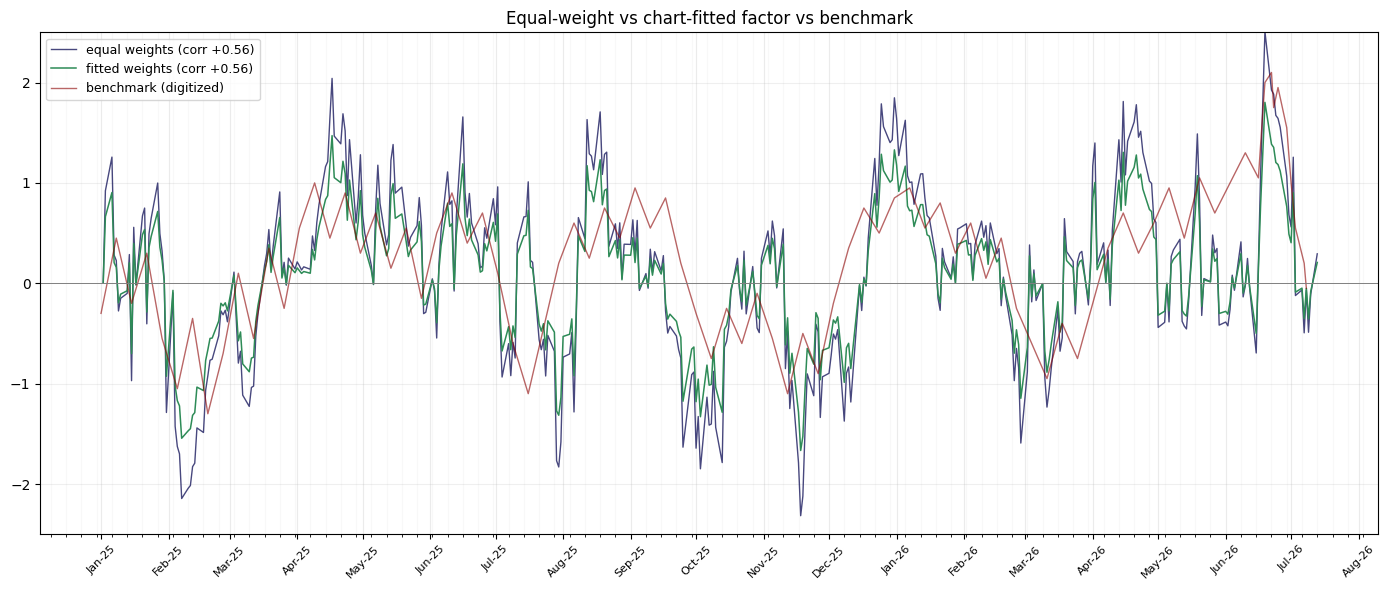

In [4]:
factor_fit = fl.build_factor(signed_z, weights)

corr_eq = pd.DataFrame({"f": factor_eq, "b": benchmark}).dropna().corr().iloc[0, 1]
corr_ft = pd.DataFrame({"f": factor_fit, "b": benchmark}).dropna().corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(factor_eq.index, factor_eq.values, color="#1a1a5e", linewidth=1.0,
        alpha=0.8, label=f"equal weights (corr {corr_eq:+.2f})")
ax.plot(factor_fit.index, factor_fit.values, color="seagreen", linewidth=1.1,
        label=f"fitted weights (corr {corr_ft:+.2f})")
if SHOW_BENCHMARK:
    ax.plot(benchmark.index, benchmark.values, color="darkred",
            linewidth=1.0, alpha=0.6, label="benchmark (digitized)")
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_ylim(-2.5, 2.5)
fl.format_time_axis(ax)  # monthly ticks: this one shows full history
ax.set_title("Equal-weight vs chart-fitted factor"
             + (" vs benchmark" if SHOW_BENCHMARK else ""))
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("factor_fitted_vs_equal.png", dpi=120)
plt.show()

### Predict with the fitted factor (same AR(1) machinery as 02)

In [5]:
def ar1_forecast(series, horizon):
    y = series.dropna()
    b, a = np.polyfit(y.values[:-1], y.values[1:], 1)
    noise_std = (y.values[1:] - (a + b * y.values[:-1])).std()
    path, spread = [], []
    value = y.iloc[-1]
    for k in range(1, horizon + 1):
        value = a + b * value
        path.append(value)
        spread.append(noise_std * np.sqrt((1 - b ** (2 * k)) / (1 - b ** 2)))
    future_dates = pd.bdate_range(y.index[-1], periods=horizon + 1)[1:]
    info = {"half_life": np.log(0.5) / np.log(b),
            "long_run_mean": a / (1 - b)}
    return future_dates, np.array(path), np.array(spread), info


fdates_ft, path_ft, spread_ft, info_ft = ar1_forecast(factor_fit, HORIZON)

pd.DataFrame({"date": fdates_ft, "path": path_ft, "spread": spread_ft}) \
  .to_csv("forecast_fitted.csv", index=False)

print(f"Fitted factor today : {factor_fit.iloc[-1]:+.2f}")
print(f"Forecast in {HORIZON}d   : {path_ft[-1]:+.2f} "
      f"(half-life {info_ft['half_life']:.1f}d, mean {info_ft['long_run_mean']:+.2f})")

Fitted factor today : +0.21
Forecast in 21d   : +0.08 (half-life 4.2d, mean +0.08)


### The head-to-head: 02's prediction vs this one

History starts at `PLOT_START` (set it at the top), weekly x-axis ticks,
both past AND upcoming events annotated — note the next FOMC inside the
forecast window: that is the day most likely to break the fan chart.

02's forecast is truncated to the same horizon so the comparison is fair.

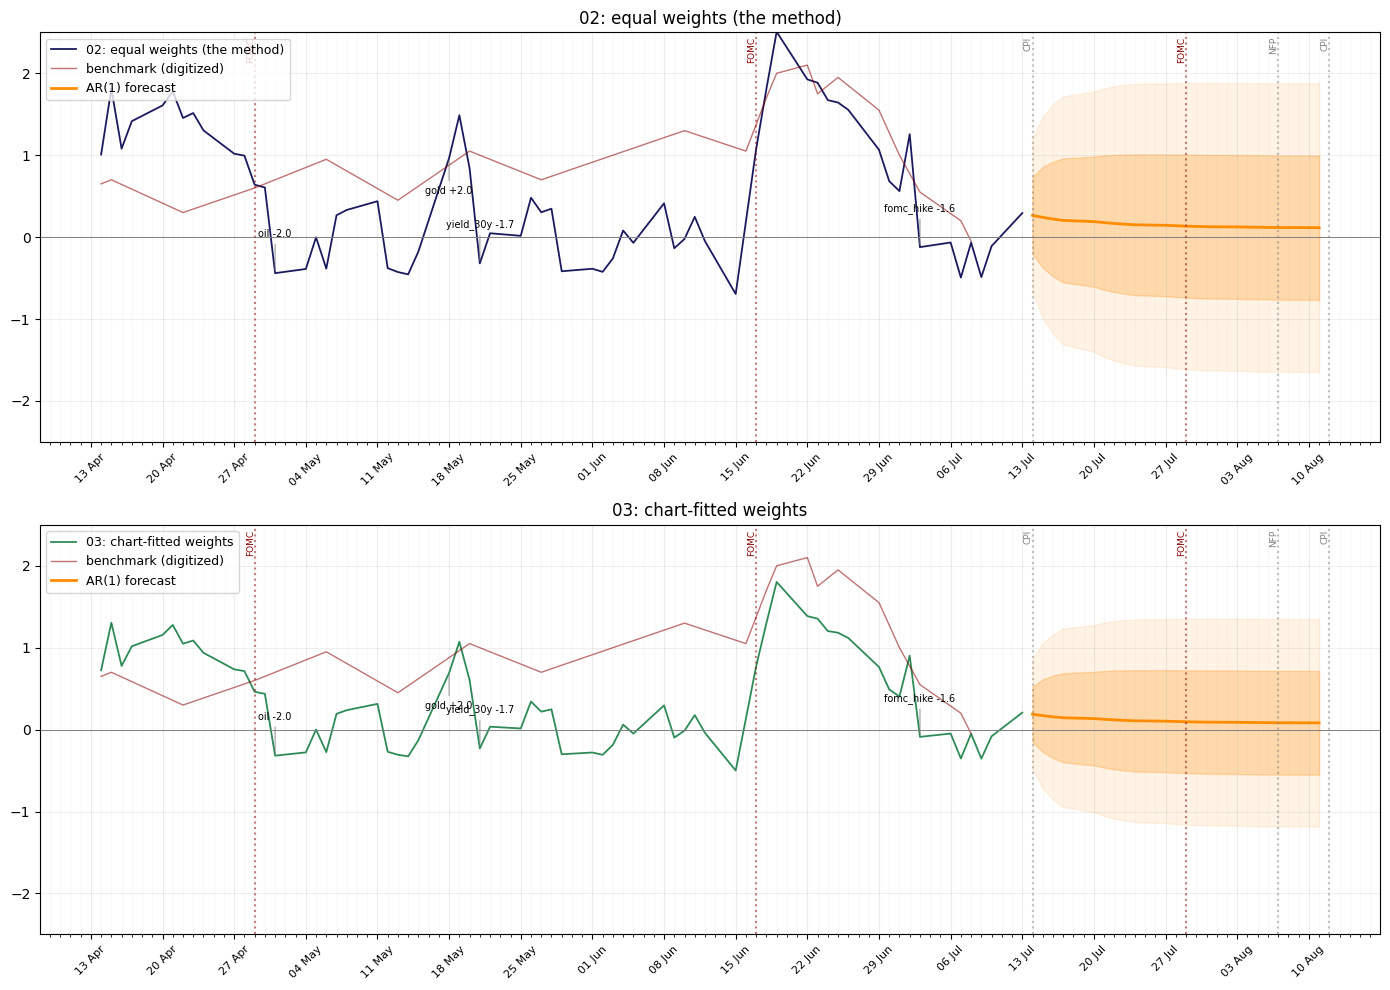

In [6]:
n_eq = min(HORIZON, len(fc_eq))
fdates_eq = fc_eq["date"].iloc[:n_eq]
path_eq = fc_eq["path"].values[:n_eq]
spread_eq = fc_eq["spread"].values[:n_eq]

hist_eq = factor_eq[factor_eq.index >= plot_start]
hist_ft = factor_fit[factor_fit.index >= plot_start]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, hist, fd, p, s, color, name in [
    (axes[0], hist_eq, fdates_eq, path_eq, spread_eq, "#1a1a5e",
     "02: equal weights (the method)"),
    (axes[1], hist_ft, fdates_ft, path_ft, spread_ft, "seagreen",
     "03: chart-fitted weights"),
]:
    ax.plot(hist.index, hist.values, color=color, linewidth=1.3, label=name)
    if SHOW_BENCHMARK:
        b_win = benchmark[benchmark.index >= plot_start]
        ax.plot(b_win.index, b_win.values, color="darkred", linewidth=1.0,
                alpha=0.55, label="benchmark (digitized)")
    ax.plot(fd, p, color="darkorange", linewidth=2, label="AR(1) forecast")
    ax.fill_between(fd, p - s, p + s, color="darkorange", alpha=0.25)
    ax.fill_between(fd, p - 2 * s, p + 2 * s, color="darkorange", alpha=0.10)
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.set_ylim(-2.5, 2.5)
    fl.format_time_axis(ax, freq="week")
    annotate(ax, hist)
    ax.set_title(name)
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("forecast_side_by_side.png", dpi=120)
plt.show()

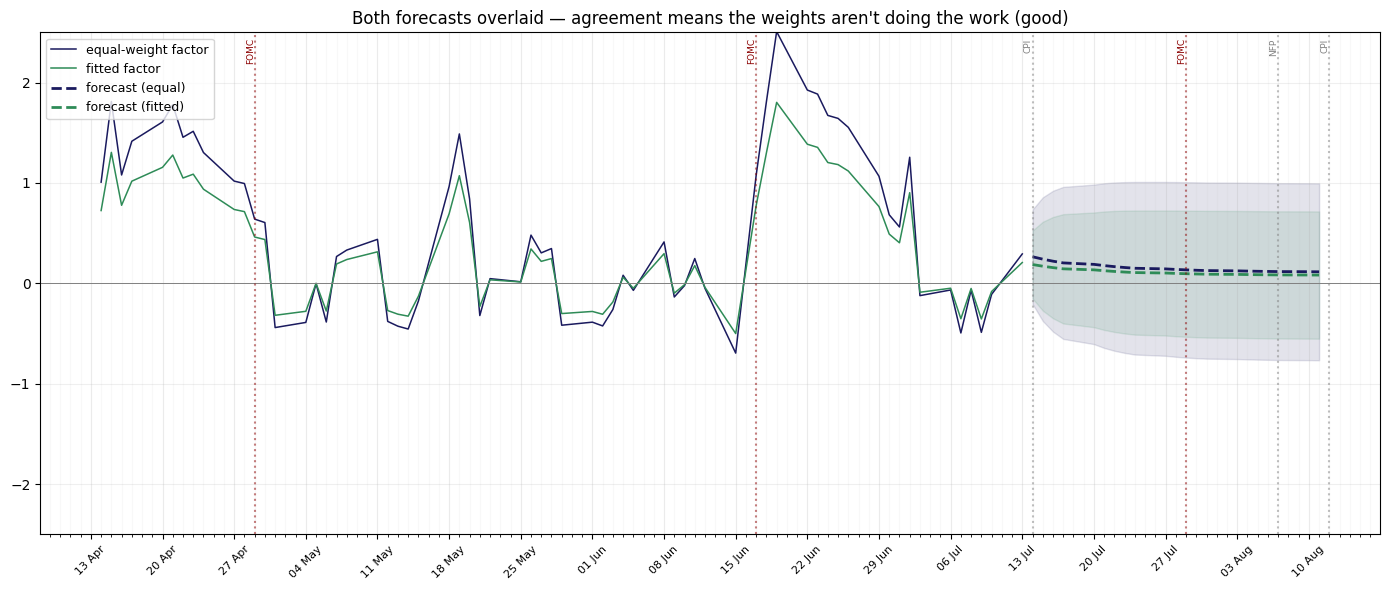

End-of-horizon gap between the two forecasts: 0.03
Small gap (< ~0.3): weights don't matter much -> trust the method.
Large gap: the fit is doing heavy lifting -> investigate components.


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hist_eq.index, hist_eq.values, color="#1a1a5e", linewidth=1.1,
        label="equal-weight factor")
ax.plot(hist_ft.index, hist_ft.values, color="seagreen", linewidth=1.1,
        label="fitted factor")
ax.plot(fdates_eq, path_eq, color="#1a1a5e", linewidth=2, linestyle="--",
        label="forecast (equal)")
ax.plot(fdates_ft, path_ft, color="seagreen", linewidth=2, linestyle="--",
        label="forecast (fitted)")
ax.fill_between(fdates_eq, path_eq - spread_eq, path_eq + spread_eq,
                color="#1a1a5e", alpha=0.12)
ax.fill_between(fdates_ft, path_ft - spread_ft, path_ft + spread_ft,
                color="seagreen", alpha=0.12)
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_ylim(-2.5, 2.5)
fl.format_time_axis(ax, freq="week")
annotate(ax)
ax.set_title("Both forecasts overlaid — agreement means the weights "
             "aren't doing the work (good)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("forecast_overlay.png", dpi=120)
plt.show()

gap = abs(path_eq[-1] - path_ft[-1])
print(f"End-of-horizon gap between the two forecasts: {gap:.2f}")
print("Small gap (< ~0.3): weights don't matter much -> trust the method.")
print("Large gap: the fit is doing heavy lifting -> investigate components.")